# Simulation-based Inference

## Solution for Exercise-2

In [1]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

## 1. Sampling from exponential distribution

### (a). Derive the quantile function for exponential distribution ( $f(x)$ = $\lambda$ exp($- \lambda x$), $\quad x$ $\ge 0$) using its CDF. Using any programming language, sample from an exponential distribution (with rate parameter 𝜆 = 5) on the basis of continuous uniform samples (𝑝 ∼ Uniform(0, 1)) utilising quantile function.

The CDF of exponential distribution is

 \begin{align*}
F(x) &= \int_{0}^{x} \lambda e^{-\lambda t} \, dt
      = 1 - e^{-\lambda x},
      \quad x \ge 0
\end{align*}

To get the quantile function $Q(p) = F^{-1}(p)$, set
\begin{align*}
p    &= F(x) = 1 - e^{-\lambda x}
      \quad\Longrightarrow\quad
      e^{-\lambda x} = 1 - p,\\
-\lambda x &= \ln(1-p)
      \quad\Longrightarrow\quad
      x = -\frac{1}{\lambda}\ln\bigl(1-p\bigr).
\end{align*}
Therefore, the quantile function is
$$
Q(p) \;=\; F^{-1}(p)
           = -\frac{1}{\lambda}\ln\bigl(1-p\bigr),
           \quad 0 \le p \le 1.
$$


In [17]:
def sample_exponential(rate=5):
    p = random.uniform(0, 1)
    x = - (1 / rate) * math.log(1 - p)
    return x

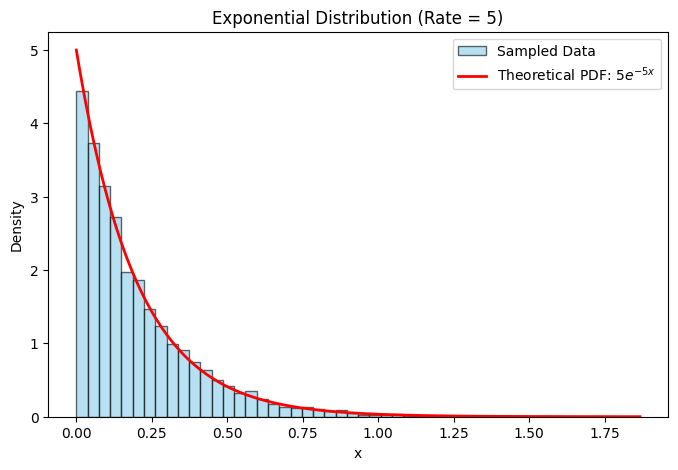

In [19]:
# Parameters
rate = 5
num_samples = 10000

# Generate samples
samples = [sample_exponential(rate) for _ in range(num_samples)]


fig, ax = plt.subplots(figsize=(8, 5))
n, bins, patches = ax.hist(samples, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Sampled Data')

x = np.linspace(0, max(samples), 200)
pdf = rate * np.exp(-rate * x)  # f(x) = 5 * exp(-5*x)


ax.plot(x, pdf, 'r-', lw=2, label=f'Theoretical PDF: $5e^{{-5x}}$') # Overlay the theoretical exponential PDF

ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('Exponential Distribution (Rate = 5)')
ax.legend()
plt.show()

### (b). Learn about (via web search) the relationship between the Poisson and exponential distribution.

Let $E_1,E_2,\dots$ be i.i.d. $\mathrm{Exp}(\lambda)$ random variables, and define the partial sums
$$
S_k \;=\;\sum_{i=1}^k E_i,\qquad k=1,2,\dots,
$$
with $S_0=0$.  Then for any $x\ge0$ and $k\in\mathbb{N}_0$,
$$
P\bigl(S_k \le x < S_{k+1}\bigr)
\;=\;
\frac{(\lambda x)^k}{k!}\,e^{-\lambda x},
$$
which is precisely the Poisson$(\lambda x)$ probability mass function
$$
P(N=k)\;=\;\frac{(\lambda x)^k}{k!}\,e^{-\lambda x},\quad k=0,1,2,\dots.
$$

### (c). Sample from a Poisson distribution (with mean parameter 5) using samples from the exponential distribution.

Let $E_1,E_2,\dots$ be i.i.d. $\mathrm{Exp}(5)$ random variables.
Now, define the partial sums
$$
S_0 = 0,\quad
S_k = \sum_{i=1}^k E_i,\quad k=1,2,\dots
$$

Set \(x = 1\).  Then the number of exponentials that fit before exceeding $x$,
$$
N \;=\; \max\{\,k\ge0 : S_k \le 1\},
$$
has the \(\mathrm{Poisson}(5)\) distribution, because
$$
P(N = k)
\;=\;
P\bigl(S_k \le 1 < S_{k+1}\bigr)
\;=\;
\frac{(5\cdot1)^k}{k!}\,e^{-5\cdot1}.
$$

Hence, to sample $N\sim\mathrm{Poisson}(5)$:
$$
\text{(i)}\quad E_i = -\tfrac1{5}\ln(U_i),\quad U_i\sim\mathrm{Uniform}(0,1),
\quad
\text{(ii)}\quad S_k = \sum_{i=1}^k E_i,
\quad
\text{(iii)}\quad
N = \max\{k : S_k \le 1\}.
$$


In [21]:
def sample_poisson(mean=5):
    """
    Generate one sample from the Poisson distribution with mean 5 using
    samples from the exponential distribution.

    Algorithm:
      1. Initialize cumulative sum S = 0 and count = 0.
      2. While S ≤ 1:
           - Generate an exponential sample and add it to S.
           - Increment count by 1.
      3. Return count - 1 as the Poisson sample.
    """
    threshold = 1.0
    cumulative_sum = 0.0
    count = 0
    while cumulative_sum <= threshold:
        cumulative_sum += sample_exponential(rate=mean)
        count += 1
    return count - 1  # the last sample pushed S over the threshold

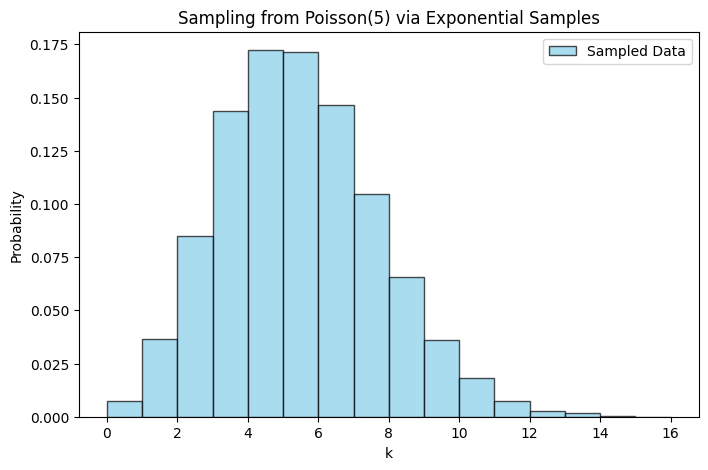

In [ ]:
num_samples = 10000 # Generate multiple Poisson samples
poisson_samples = [sample_poisson(mean=5) for _ in range(num_samples)]

# Visualize the generated Poisson samples using a histogram.
plt.figure(figsize=(8, 5))
# Use integer bins from the minimum to maximum values of the samples.
bins = range(min(poisson_samples), max(poisson_samples) + 2)
plt.hist(poisson_samples, bins=bins, density=True, color='skyblue',
         edgecolor='black', alpha=0.7, label='Sampled Data')


plt.xlabel('k')
plt.ylabel('Probability')
plt.title('Sampling from Poisson(5) via Exponential Samples')
plt.legend()
plt.show()

## 2. Importance Sampling

### Estimate the tail probability of 𝜃 = 𝑃 (𝑋 > 2) where 𝑋 is Cauchy distributed.

## Cauchy Distribution

For location parameter $ x_0 $ and scale $ \gamma > 0 $:

PDF:
$
p(x) = \frac{1}{\pi \gamma} \cdot \frac{1}{1 + \left(\frac{x - x_0}{\gamma}\right)^2}
$

CDF:
$
F(x) = \frac{1}{\pi} \arctan\!\left(\frac{x - x_0}{\gamma}\right) + \frac{1}{2}
$

### Standard Cauchy ( $ x_0 = 0, \gamma = 1 $ )

PDF:
$
p(x) = \frac{1}{\pi} \cdot \frac{1}{1 + x^2}
$

CDF: $F(x) = \frac{1}{\pi} \arctan(x) + \frac{1}{2}$

Quantile Function: $
Q(p) = \gamma \tan\!\big(\pi(p - \tfrac{1}{2})\big)
$

In [2]:
def cauchy_quantile(p):
    return np.tan(np.pi * (p - 0.5))

def cauchy_pdf(x):
    return 1.0 / (math.pi * (1 + x**2))

def cauchy_cdf(x):
    return 0.5 + (1.0/math.pi) * math.atan(x)

We are interested in the quantity $\theta=P(X>2)$ which can be expressed as

$$  
\mathbb{E}_X[ \mathbb{1}_{\{X>2\}}(X) ]  =   \int_{-\infty}^\infty  \mathbb{1}_{\{x>2\}}(x) p(x) dx = P_X(X>2).
$$


### (a) Use regular Monte Carlo sampling.

In [24]:
S = 1000000  #no. of samples

uniform_samples = np.random.uniform(0, 1, S)

# Generate Cauchy samples using the quantile function
cauchy_samples = cauchy_quantile(uniform_samples)

# estimated tail probability: P(X > 2)
tail_probability_estimate = np.mean(cauchy_samples > 2)

# true tail probability:
true_tail_probability = 1 - cauchy_cdf(2)

print("Estimated tail probability P(X > 2):", tail_probability_estimate)
print("True tail probability P(X > 2):", true_tail_probability)

Estimated tail probability P(X > 2): 0.147081
True tail probability P(X > 2): 0.14758361765043326


### (b) Use importance sampling with a standard-normal distribution as the proposal distribution.

In [25]:
# proposal density: Standard Normal
def q_normal(x):
    return (1.0 / np.sqrt(2 * math.pi)) * np.exp(-x**2 / 2)

S = 10000

proposal_samples = np.random.normal(loc=0, scale=1, size=S)

#importance weights: w(x) = p(x) / q(x)
weights = np.array([cauchy_pdf(x) / q_normal(x) for x in proposal_samples])

# For tail probability estimation, define f(x)= I{x > 2}
indicator = (proposal_samples > 2).astype(np.float64)

# Self-normalized importance sampling estimator for the tail probability:
# theta ≈ (sum_{i} I{x_i>2} * w(x_i)) / (sum_{i} w(x_i))
theta_estimated = np.sum(indicator * weights) / np.sum(weights)

# Computing the true tail probability using the Cauchy CDF:
theta_true = 1 - cauchy_cdf(2)

print("Estimated tail probability P(X > 2):", theta_estimated)
print("True tail probability P(X > 2):", theta_true)

Estimated tail probability P(X > 2): 0.09198802135914505
True tail probability P(X > 2): 0.14758361765043326


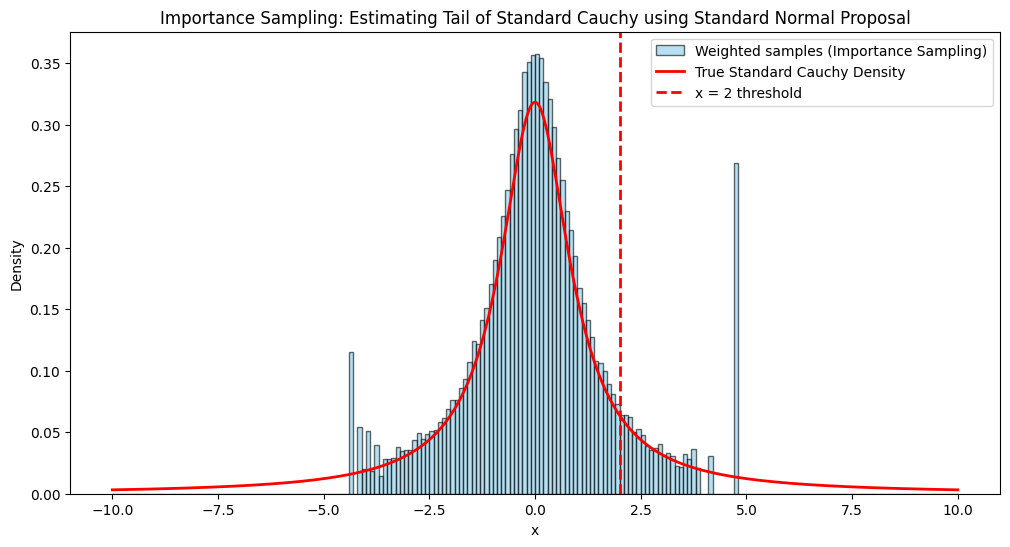

In [10]:
# Visualization

plt.figure(figsize=(12, 6))
normalized_weights = weights / np.sum(weights)

bins = 200

plt.hist(proposal_samples, bins=bins, range=(-10,10), weights=normalized_weights,
         density=True, alpha=0.6, color='skyblue', edgecolor='black',
         label='Weighted samples (Importance Sampling)')

x_grid = np.linspace(-10, 10, 500)
cauchy_density = np.array([cauchy_pdf(x) for x in x_grid])
plt.plot(x_grid, cauchy_density, 'r-', lw=2, label='True Standard Cauchy Density')

# Mark the threshold x = 2 with a vertical dashed red line.
plt.axvline(2, color='red', linestyle='--', lw=2, label='x = 2 threshold')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Importance Sampling: Estimating Tail of Standard Cauchy using Standard Normal Proposal')
plt.legend()
plt.show()

### (c) Use importance sampling with a truncated Cauchy distribution as the proposal distribution.

In [13]:
# full‐CDF and density of Cauchy(0, s)
def cdf_full(x):
    return 0.5 + (1.0/math.pi) * math.atan(x/s)

def pdf_full(x):
    return 1.0/(math.pi * s * (1 + (x/s)**2))

## Proposal distribution $ q(x)$

You define a **truncated Cauchy** on $[a,b] = [2,1000]$:

### Normalization constant

$$
Z = F(b) - F(a)
$$

### Proposal density

$$
q(x) =
\begin{cases}
\frac{f(x)}{Z}, & x \in [a,b] \\
0, & \text{otherwise}
\end{cases}
$$

So $ q(x) $ is the original Cauchy density **conditioned on** $ x \in [2,b]$:

$$
q(x) = f(x \mid a \le X \le b)
$$

---

## Sampling from $q(x)$

We use **inverse transform sampling**.

### Step 1: sample in probability space
$$
u \sim \text{Uniform}(0,1)
$$

### Step 2: rescale to truncated probability interval
$$
p = u \cdot Z + F(a)
$$

This maps:
$$
[0,1] \rightarrow [F(a), F(b)]
$$

So:
$$
p \sim \text{Uniform}(F(a), F(b))
$$

### Step 3: map back to sample space

$$
x = F^{-1}(p) = s \tan\left(\pi(p - 1/2)\right)
$$

So the final samples satisfy:
$$
X_i \sim q(x)
$$

---

## Importance weights

The general importance sampling weight is:

$$
w(x) = \frac{f(x)}{q(x)}
$$

Substitute the truncated proposal:

$$
q(x) = \frac{f(x)}{Z}
$$

So:

$$
w(x) = \frac{f(x)}{f(x)/Z}
$$

---

## Simplification of weights

The density terms cancel:

$$
w(x) = Z
$$

So the weight is **constant for all samples**.

---

### Final consequence

Because weights are constant:

- Standard IS estimator:
$$
\hat{\theta}_{IS} = \frac{1}{N} \sum w(x_i) h(x_i) = Z \cdot \frac{1}{N} \sum h(x_i)
$$

- Since all samples satisfy $ x_i \ge a = 2 $, we have:
$
h(x_i) = 1
$

So:
$$
\hat{\theta}_{IS} = Z
$$


In [27]:
true_tail_prob = 1 - cauchy_cdf(2)

# Proposal: One‐sided truncated Cauchy on [2, b]

a = 2.0         # lower truncation at threshold
b = 1000.0       # approximate +∞
s = 0.5         # scale of proposal



# normalization constant for truncation [a,b]
Z = cdf_full(b) - cdf_full(a)

def q_prop(x):
    return (pdf_full(x) / Z) if (a <= x <= b) else 0.0

def Q_prop(u):
    p = u * Z + cdf_full(a)
    return s * math.tan(math.pi * (p - 0.5))


# Importance Sampling

S = 100
u = np.random.rand(S)
xs = np.array([Q_prop(ui) for ui in u])       # proposal samples in [2,b]
ws = np.array([cauchy_pdf(x)/q_prop(x) for x in xs])  # importance weights

# estimate P(X>2) = E_q[ I{x>2} * w(x) ] / E_q[w(x)]
# but here all xs>2 by construction, so indicator=1
theta_hat = ws.mean()  #we need unnormalized formula:

print("Estimated P(X>2) via one‐sided truncated Cauchy proposal:", theta_hat)
print("True P(X>2):", true_tail_prob)


Estimated P(X>2) via one‐sided truncated Cauchy proposal: 0.14681894253596628
True P(X>2): 0.14758361765043326


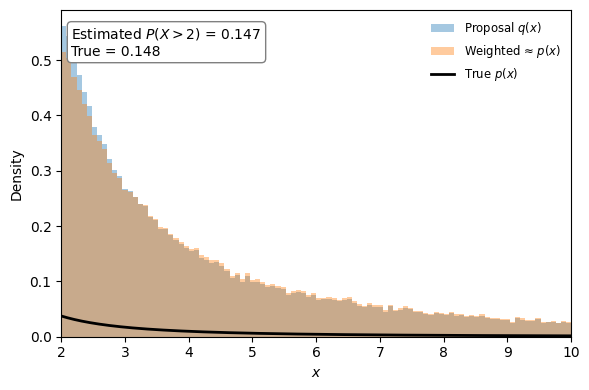

In [16]:
fig, ax = plt.subplots(1,1, figsize=(6,4))


ax.hist(xs, bins=100, range=(2,10), density=True,
        alpha=0.4, label='Proposal $q(x)$')

ax.hist(xs, bins=100, range=(2,10),
        weights=ws, density=True,
        alpha=0.4, label='Weighted ≈ $p(x)$')

x_grid = np.linspace(2,10,500)
ax.plot(x_grid, [pdf_full(x) for x in x_grid],
        'k-', lw=2, label='True $p(x)$')

ax.set_xlim(2,10)
ax.set_xlabel('$x$')
ax.set_ylabel('Density')
ax.legend(fontsize='small', ncol=1, loc='upper right', frameon=False)


ax.text(0.02, 0.95,
        f'Estimated $P(X>2)$ = {theta_hat:.3f}\nTrue = {true_tail_prob:.3f}',
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))

plt.tight_layout()
plt.show()